#### varaibles
- real gdp per capita growth - trend + cycle of real values? diff og gdp real per capita
- inflation = inflation trend + measurement errors???
- short rate = inflation trend + real rate trend 
- long rate = inflation trend + real rate trend + term trend
- inflation expectations??
- growth expextations??
- 

In [1]:
import Pkg
Pkg.activate("../")

using Revise

includet("../src/TCVAR/TCVAR.jl")

  Activating project at `~/projects/MacroFinanceScenarios`


In [3]:
using .TCVAR
using DataFrames, XLSX, TimeSeries
using StatsBase
using LinearAlgebra
using Plots


In [4]:
df = DataFrame(XLSX.readtable("../data/DelNegro.xlsx", "Sheet1"))
allowmissing!(df)

df[df.Date .>= Date(2008, 10, 1), :BILL] .= missing


data = TimeArray(df[!,[:Date, :Pi, :EPi, :BILL, :EBILL, :TBlong]]; timestamp = :Date)
presample, data = data[Date(1954,01,01):Date(1959,12,31)], data[Date(1960,01,01):Date(2016,12,31)]


display(presample)
display(data) 


24×5 TimeArray{Union{Missing, Float64}, 2, Date, Matrix{Union{Missing, Float64}}} 1954-01-01 to 1959-10-01
┌────────────┬──────────┬─────────┬──────┬─────────┬────────┐
│            │ Pi       │ EPi     │ BILL │ EBILL   │ TBlong │
├────────────┼──────────┼─────────┼──────┼─────────┼────────┤
│ 1954-01-01 │  2.01108 │ missing │ 1.06 │ missing │   2.71 │
│ 1954-04-01 │ -0.55724 │ missing │ 0.79 │ missing │   2.63 │
│ 1954-07-01 │ -1.31896 │ missing │ 0.88 │ missing │   2.58 │
│ 1954-10-01 │ -0.38172 │ missing │ 1.02 │ missing │   2.64 │
│ 1955-01-01 │   1.3246 │ missing │ 1.22 │ missing │   2.81 │
│ 1955-04-01 │  0.40624 │ missing │ 1.48 │ missing │   2.86 │
│ 1955-07-01 │  1.59788 │ missing │ 1.86 │ missing │   2.98 │
│ 1955-10-01 │  1.11152 │ missing │ 2.34 │ missing │   2.95 │
│ 1956-01-01 │  1.63748 │ missing │ 2.33 │ missing │   2.95 │
│ 1956-04-01 │  2.70964 │ missing │ 2.57 │ missing │   3.07 │
│ 1956-07-01 │  3.91252 │ missing │ 2.58 │ missing │   3.19 │
│     ⋮      │    ⋮     │

228×5 TimeArray{Union{Missing, Float64}, 2, Date, Matrix{Union{Missing, Float64}}} 1960-01-01 to 2016-10-01
┌────────────┬──────────┬────────┬─────────┬─────────┬────────┐
│            │ Pi       │ EPi    │ BILL    │ EBILL   │ TBlong │
├────────────┼──────────┼────────┼─────────┼─────────┼────────┤
│ 1960-01-01 │  0.52872 │ 1.6827 │    3.87 │ missing │   4.28 │
│ 1960-04-01 │  2.11204 │ 1.6827 │    2.99 │ missing │   4.16 │
│ 1960-07-01 │  1.53004 │ 1.6827 │    2.36 │ missing │   3.87 │
│ 1960-10-01 │  1.77444 │ 1.6827 │    2.31 │ missing │   3.93 │
│ 1961-01-01 │   0.7474 │ 1.6827 │    2.35 │ missing │   3.85 │
│ 1961-04-01 │  -0.0452 │ 1.6827 │     2.3 │ missing │   3.81 │
│ 1961-07-01 │   1.4696 │ 1.6827 │     2.3 │ missing │    4.0 │
│ 1961-10-01 │  0.45052 │ 1.6827 │    2.46 │ missing │   4.03 │
│ 1962-01-01 │  1.77756 │ 1.6827 │    2.72 │ missing │   4.09 │
│ 1962-04-01 │  1.38888 │ 1.6827 │    2.72 │ missing │   3.94 │
│ 1962-07-01 │  1.04924 │ 1.6827 │    2.84 │ missing │   4.0

In [5]:
n = 5 #number of observatin variables
nt = 3 #number of trends

priors = (
        initial_trend_mean = [2., .5, 1.],
        initial_cycle_mean = zeros(n),
        initial_trend_covariance = diagm(fill(1,nt)),
        trend_covariance_df = 100,
        trend_covariance_mean = diagm([2., 1., 1.].^2 ./ 400),
        cycle_coeff_mean = zeros(n, n),
        cycle_coeff_shrinkage_param = .2,
        cycle_covariance_mean = diagm([2., 1., 1., .5, 1.]),  
        cycle_covariance_df = n+2
        )


(initial_trend_mean = [2.0, 0.5, 1.0], initial_cycle_mean = [0.0, 0.0, 0.0, 0.0, 0.0], initial_trend_covariance = [1 0 0; 0 1 0; 0 0 1], trend_covariance_df = 100, trend_covariance_mean = [0.01 0.0 0.0; 0.0 0.0025 0.0; 0.0 0.0 0.0025], cycle_coeff_mean = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], cycle_coeff_shrinkage_param = 0.2, cycle_covariance_mean = [2.0 0.0 … 0.0 0.0; 0.0 1.0 … 0.0 0.0; … ; 0.0 0.0 … 0.5 0.0; 0.0 0.0 … 0.0 1.0], cycle_covariance_df = 7)

In [10]:
n_trends = 3
n_variables = 5
initial_state_covariance = [priors.initial_trend_covariance zeros(n_trends, n_variables)
                            zeros(n_variables, n_trends) priors.cycle_covariance_mean]

8×8 Matrix{Float64}:
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  2.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.5  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0

In [6]:
priors.trend_covariance_mean

3×3 Matrix{Float64}:
 0.01  0.0     0.0
 0.0   0.0025  0.0
 0.0   0.0     0.0025

In [11]:
observation_trend_mapping  = [1 0 0  
                              1 0 0  
                              1 1 0  
                              1 1 0  
                              1 1 1 ]



trend_states_samples, cycle_states_samples, trend_covariance_samples, betas_samples, sigmas_samples = TCVAR.gibbs_sampler(values(data), observation_trend_mapping, priors; burnin = 50_000, n_samples = 50_000, thin=25, logging=false)

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.68)  
cycle_states_mean, cycle_states_lower, cycle_states_upper = TCVAR.compute_posterior_statistics(cycle_states_samples, credible_level=0.95) 

([-1.0697827919508436 0.08419720774317471 … -0.025378060094321777 0.07201406874821806; 0.5503789616184611 0.12103896199758125 … -0.05111417690293657 -0.002983532814829746; … ; 0.19871593614464106 0.7437559360194156 … -0.04611965649509799 -1.0711783966204902; 0.8475904949266965 0.7055104948086032 … -0.01868667881308546 -0.5092840647035602], [-1.792075623520809 -0.6380956171261645 … -1.8023946740505237 -1.0766639810843766; -0.17635770087683303 -0.6056977045475764 … -1.6963303894393964 -1.1728652776608726; … ; -0.6859283177087637 -0.1408883245067491 … -1.9000109530059077 -2.7263638680534226; -0.05180557348220021 -0.193885589701373 … -2.0149063567632397 -2.1787495359849873], [-0.3421792191885885 0.8118007846742136 … 1.7039942359997948 1.117658793267372; 1.235865424469368 0.8065254441453619 … 1.712612380391362 1.0376391488935952; … ; 1.101068285098011 1.646108287724657 … 1.866835784896215 0.17996054837899622; 1.834202189875576 1.6921221990014614 … 1.932806774291675 0.7755492645845772])

In [ ]:
priors.initial_trend_covariance

3×3 Matrix{Int64}:
 1  0  0
 0  1  0
 0  0  1

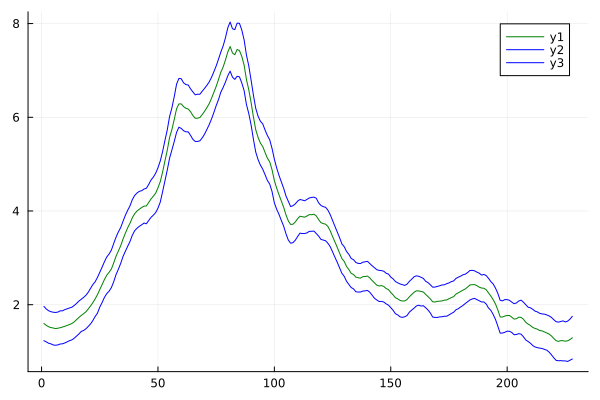

In [12]:
st = 1
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

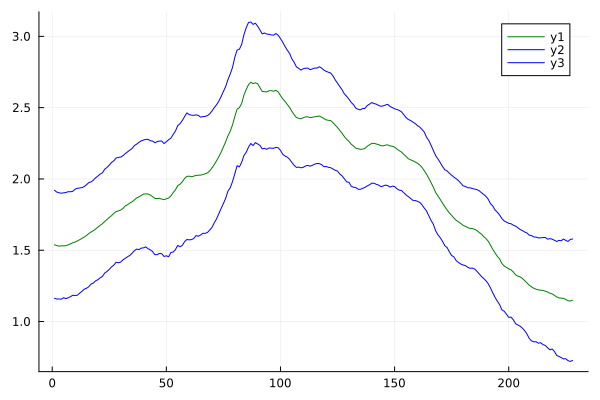

In [13]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

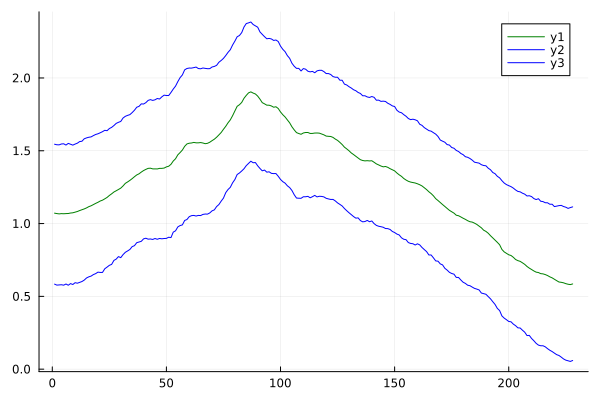

In [14]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

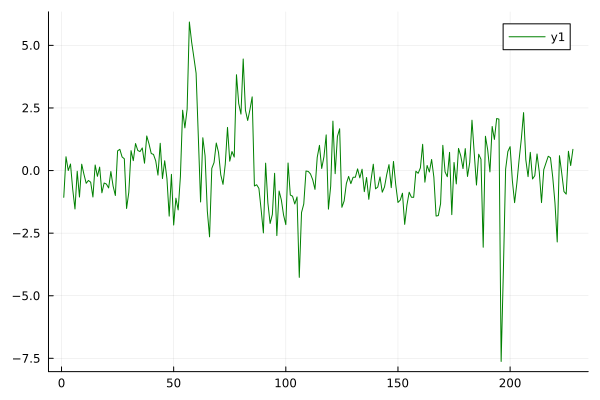

In [16]:
st=1
plot(cycle_states_mean[:,st], color="green" )

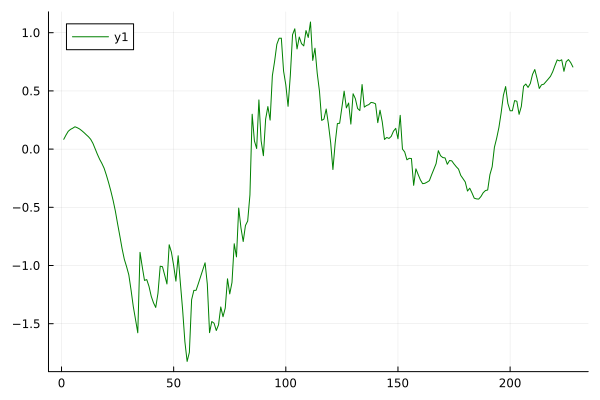

In [17]:
st=2
plot(cycle_states_mean[:,st], color="green" )

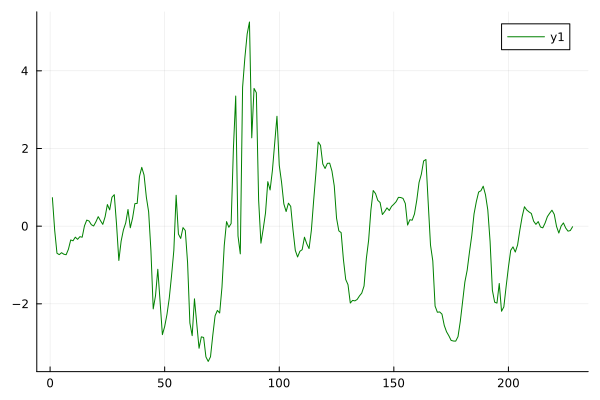

In [18]:
st=3
plot(cycle_states_mean[:,st], color="green" )

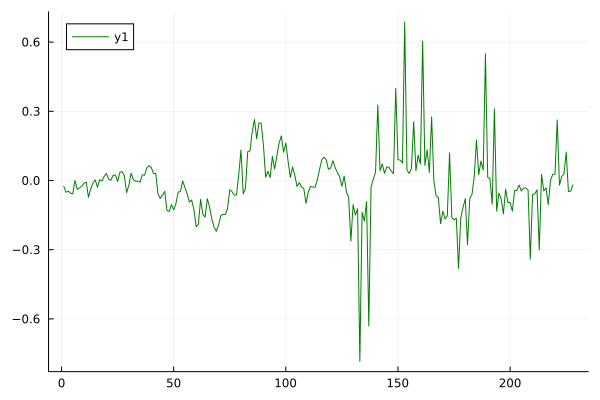

In [19]:
st=4
plot(cycle_states_mean[:,st], color="green" )

In [20]:
summarystats(trend_covariance_samples)

Summary Statistics

  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

         Στ1    0.0234    0.0052    0.0001   1934.4641   1712.6986    1.0000   ⋯
         Στ2    0.0013    0.0015    0.0000   2123.0516   1846.5308    1.0007   ⋯
         Στ3    0.0012    0.0013    0.0000   2058.8603   1739.0614    1.0014   ⋯
         Στ4    0.0013    0.0015    0.0000   2123.0516   1846.5308    1.0007   ⋯
         Στ5    0.0033    0.0006    0.0000   1654.1097   1883.7650    1.0000   ⋯
         Στ6    0.0004    0.0004    0.0000   1976.7297   1693.9080    0.9997   ⋯
         Στ7    0.0012    0.0013    0.0000   2058.8603   1739.0614    1.0014   ⋯
         Στ8    0.0004    0.0004    0.0000   1976.7297   1693.9080    0.9997   ⋯
         Στ9    0.0030    0.0005    0.0000   1923.6439   1883.7650    0.9996   ⋯

                                                                1 column omitted


In [21]:
summarystats(betas_samples)

Summary Statistics

  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

          β1    0.4019    0.0897    0.0020   2079.4855   1967.6740    0.9999   ⋯
          β2   -0.1109    0.1813    0.0041   1935.3692   1922.3943    0.9996   ⋯
          β3    0.1113    0.0927    0.0021   1978.5379   1901.7701    1.0002   ⋯
          β4    0.0046    0.1916    0.0043   1939.6709   1672.1236    1.0001   ⋯
          β5   -0.2606    0.1296    0.0029   1981.4800   1976.5714    1.0004   ⋯
          β6   -0.0083    0.0324    0.0007   1952.2668   1751.6456    1.0008   ⋯
          β7    0.7123    0.0932    0.0020   2164.3295   1778.1331    1.0013   ⋯
          β8    0.0066    0.0385    0.0009   2020.1826   1959.9280    1.0021   ⋯
          β9   -0.0043    0.0537    0.0012   1982.3796   1997.1309    1.0000   ⋯
         β10    0.0943    0.0569    0.0012   2129.3810   1962.0911    0.9996   ⋯
       

In [22]:
summarystats(sigmas_samples)

Summary Statistics

  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

         Σc1    1.7941    0.1888    0.0043   1964.2162   1678.3796    1.0007   ⋯
         Σc2    0.0424    0.0607    0.0014   1979.3455   1678.5851    1.0011   ⋯
         Σc3    0.1072    0.1044    0.0022   2191.3684   2047.4180    1.0006   ⋯
         Σc4    0.0017    0.2107    0.0047   1994.4807   1974.5009    1.0031   ⋯
         Σc5    0.1205    0.0739    0.0017   1933.9097   1819.6342    1.0005   ⋯
         Σc6    0.0424    0.0607    0.0014   1979.3455   1678.5851    1.0011   ⋯
         Σc7    0.2805    0.0928    0.0021   2083.5408   1850.6777    1.0032   ⋯
         Σc8   -0.0007    0.0484    0.0011   1974.3605   1970.6015    1.0007   ⋯
         Σc9   -0.0024    0.0836    0.0018   2145.2859   2046.6150    1.0002   ⋯
        Σc10    0.0390    0.0831    0.0019   1966.7155   1923.0043    0.9996   ⋯
       

In [23]:
plot(betas_samples)

┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1522
┌ Warning: seriestype density has been moved to StatsPlots.  To use: `Pkg.add("StatsPlots"); using StatsPlots`
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.

LoadError: The backend must not support the series type Val{:density}, and there isn't a series recipe defined.

In [26]:
Σc = mean(sigmas_samples).nt.mean
Σc = reshape(Σc, n, n)
display(Σc)

β = mean(betas_samples).nt.mean
β = reshape(β, n, n*1)
display(β)

Στ = mean(trend_covariance_samples).nt.mean
Στ = reshape(Στ, nt, nt)
display(cov2cor(Στ))
display(diag(Στ) .^ .5)

5×5 Matrix{Float64}:
 1.79411      0.0424067     0.107201      0.00168398  0.120538
 0.0424067    0.280499     -0.000688154  -0.00238186  0.0390318
 0.107201    -0.000688154   0.709402      0.025241    0.100141
 0.00168398  -0.00238186    0.025241      0.853156    0.00845605
 0.120538     0.0390318     0.100141      0.00845605  0.475342

5×5 Matrix{Float64}:
  0.401899    -0.00832014   0.0429888  -0.0062348   -0.0359921
 -0.110923     0.712294     0.104339   -0.00848358   0.131948
  0.111276     0.00664144   0.825852    0.0432068    0.0519225
  0.00460987  -0.00433078   0.0367354   0.0277545    0.00855234
 -0.260648     0.0942786   -0.0249877   0.0138357    0.768959

3×3 Matrix{Float64}:
 1.0       0.151828  0.142649
 0.151828  1.0       0.120919
 0.142649  0.120919  1.0

3-element Vector{Float64}:
 0.15282605806088212
 0.057652243368346144
 0.0548315413071181

In [27]:
display(diag(Σc) .^ .5)

display(diag(Στ) .^ .5)

5-element Vector{Float64}:
 1.3394439805855263
 0.5296218035391672
 0.8422602583460558
 0.9236646804189055
 0.6894508021175776

3-element Vector{Float64}:
 0.15282605806088212
 0.057652243368346144
 0.0548315413071181

In [ ]:
model = tc_var(observation_tend_mapping, β, Στ, Σc, priors.initial_trend_mean, priors.initial_cycle_mean, priors.initial_trend_covariance, priors.cycle_covariance_mean)

initial_states = [trend_states_mean[end,:]; cycle_states_mean[end,:]]

n_samples = 2_000
T = 100
states = zeros(n_samples, T, 8)

observations = zeros(n_samples, T, n)

for s in 1:2_000
    states[s, :, :], observations[s, :, :] = sample(model, initial_states, T)
end


UndefVarError: UndefVarError: `observation_tend_mapping` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations, (3, 2, 1))[[1,2],:,:] ./400
periods = [1, 5, 10, 25]
freq = 4
assets_names = ["GDP", "CPI"]
ret_in_years = cum_returns_in_periods(transformed_scenarios, periods, freq, true)
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
transformed_scenarios = permutedims(observations[:,:,[3,4]] , (3, 2, 1))
freq = 4

transformed_scenarios = transformed_scenarios[:,freq:freq:end,:]

periods = [1, 5, 10, 25]


assets_names = ["ShortRate", "LongRate"]
ret_in_years = transformed_scenarios = transformed_scenarios[:,periods,:]
print_scenarios_summary(ret_in_years, assets_names, string.(periods))

for a in 1:2
    print_scenarios_percentiles(ret_in_years[a, :, :], [.01, 0.025, .05, .25, .5, .75, .95, .975, .99], string.(periods), string.(assets_names[a]))
end  

UndefVarError: UndefVarError: `observations` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
n_observations = size(model.T,1)
n_trends = 4
n_time_steps = size(data,1)
n_draws = 1000
trends_states = zeros(n_draws, n_time_steps, n_trends)

for s in 1:n_draws
    state_smoothed_samples = carter_kohn_sampler(model, values(data))
    trends_states[s,:,:] = state_smoothed_samples[:, 1:n_trends]
end

trend_states_mean, trend_states_lower, trend_states_upper = TCVAR.compute_posterior_statistics(trend_states_samples, credible_level=0.95) 

UndefVarError: UndefVarError: `model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 2
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
st = 3
plot(trend_states_mean[:,st], color="green" )
plot!(trend_states_lower[:,st], color="blue")
plot!(trend_states_upper[:,st], color="blue")

UndefVarError: UndefVarError: `trend_states_mean` not defined in `Main`
Suggestion: check for spelling errors or missing imports.